In [17]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Literal


FILE_PATH = Path('../output/structured_data.xlsx')
df = pd.read_excel(FILE_PATH)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Literal, Sequence


def plot_delta_lines(
    df: pd.DataFrame,
    fungo: str,
    sistema: str = "B",
    *,
    analise: str = "IER",
    concentracoes: list[int] | None = None,
    dias_full: Sequence[int] = (0, 7, 14),
    figsize_per_col: int = 5,
    toxicity_bands: bool = False,
    toxicity_alpha: float = 0.30,
    show_toxicity_legend: bool = True,
    toxicity_legend_position: Literal["top", "bottom"] = "bottom",
    xpad: float = 1.0,
    show_plot = False
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plots mean values across 3 days (default 0–7–14) for non-inoculated vs inoculated systems,
    faceted by concentration.

    Behavior:
      - 0% subplot is removed (0 is filtered out of concentracoes).
      - Line (system) legend is placed at the bottom.
      - Toxicity bands optional.
      - Toxicity legend is TOP-only (if toxicity_legend_position == "top"); never bottom.
      - If toxicity bands are enabled, y-axis major ticks match the band boundaries.
      - Legends are centered on the gap between the middle subplots (e.g., between panels 2 and 3 for 4 panels).
      - Suptitle is horizontally centered over the plots (same x as the legends), not over the whole figure.

    Required df columns:
      - fungo, analise, concentracao, sistema, dia, valor
    """
    # -----------------------------
    # Visual tuning
    # -----------------------------
    LINEWIDTH = 2.2
    MARKERSIZE = 6
    GRID_ALPHA = 0.25
    LABEL_FONTSIZE = 15
    TICK_FONTSIZE = 15
    TITLE_FONTSIZE = 15
    SUPTITLE_FONTSIZE = 18

    # NEW: independent font controls for y-label and bottom legend
    SYSTEM_LEGEND_FONTSIZE = 20
    YLABEL_FONTSIZE = 18

    if sistema == "A":
        cor_sistema = 1
    else:
        cor_sistema = 2

    if concentracoes is None:
        concentracoes = [0, 25, 50, 75, 100]

    # Remove 0% subplot
    concentracoes = [int(c) for c in concentracoes if int(c) != 0]
    if not concentracoes:
        raise ValueError("After removing 0%, concentracoes is empty. Provide non-zero concentrations.")

    dias_full = tuple(dias_full)
    if len(dias_full) != 3:
        raise ValueError("dias_full must contain exactly 3 day values (e.g., (0, 7, 14)).")
    d0, d1, d2 = dias_full

    sistema_nao_inoculado = sistema
    sistema_inoculado = f"{sistema}I"

    # -----------------------------
    # Line color palettes
    # -----------------------------
    if cor_sistema == 1:
        cor_nao_inoc = "#1f77b4"  # blue
        cor_inoc = "#ff7f0e"      # orange
    elif cor_sistema == 2:
        cor_nao_inoc = "#2ca02c"  # green
        cor_inoc = "#444444"      # dark gray
    else:
        raise ValueError("cor_sistema must be 1 or 2")

    # -----------------------------
    # Filter + pre-aggregate means
    # -----------------------------
    df_base = df.loc[
        df["fungo"].astype(str).str.contains(fungo, case=False, na=False)
        & df["analise"].astype(str).str.contains(analise, case=False, na=False),
        ["concentracao", "sistema", "dia", "valor"],
    ].copy()

    df_base["valor"] = pd.to_numeric(df_base["valor"], errors="coerce")

    means = df_base.groupby(["concentracao", "sistema", "dia"], observed=True)["valor"].mean()

    def mean_val(conc: int, sist: str, day: int) -> float:
        return float(means.get((conc, sist, day), np.nan))

    # -----------------------------
    # Figure & axes (single row)
    # -----------------------------
    ncols = len(concentracoes)

    # Slightly taller to host bottom legend cleanly
    fig_w = max(8.0, float(figsize_per_col) * ncols)
    fig_h = 5.8

    fig, axes = plt.subplots(1, ncols, figsize=(fig_w, fig_h), sharey=True)
    axes = np.atleast_1d(axes)

    y_vals: list[float] = []
    system_handles = None  # populated from first subplot

    # Precompute x limits with padding
    x0, x1 = min(dias_full), max(dias_full)
    pad = float(xpad)

    # -----------------------------
    # Plot per concentration
    # -----------------------------
    for ax, conc in zip(axes, concentracoes):
        v0_nao = mean_val(conc, sistema_nao_inoculado, d0)
        v0_inoc = mean_val(conc, sistema_inoculado, d0)
        baseline = float(np.nanmean([v0_nao, v0_inoc]))

        nao_d1 = mean_val(conc, sistema_nao_inoculado, d1)
        inoc_d1 = mean_val(conc, sistema_inoculado, d1)
        nao_d2 = mean_val(conc, sistema_nao_inoculado, d2)
        inoc_d2 = mean_val(conc, sistema_inoculado, d2)

        for v in (baseline, nao_d1, inoc_d1, nao_d2, inoc_d2):
            if pd.notna(v):
                y_vals.append(float(v))

        l1 = ax.plot(
            (d0, d1, d2),
            (baseline, nao_d1, nao_d2),
            marker="o",
            linewidth=LINEWIDTH,
            markersize=MARKERSIZE,
            color=cor_nao_inoc,
            label=sistema_nao_inoculado,
        )[0]
        l2 = ax.plot(
            (d0, d1, d2),
            (baseline, inoc_d1, inoc_d2),
            marker="o",
            linewidth=LINEWIDTH,
            markersize=MARKERSIZE,
            color=cor_inoc,
            label=sistema_inoculado,
        )[0]

        if system_handles is None:
            system_handles = [l1, l2]

        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(f"{conc}%", fontsize=TITLE_FONTSIZE)
        ax.grid(True, alpha=GRID_ALPHA)
        ax.tick_params(labelsize=TICK_FONTSIZE)
        ax.set_xticks((d0, d1, d2))
        ax.set_xlim(x0 - pad, x1 + pad)
        ax.set_xlabel("Dia", fontsize=LABEL_FONTSIZE)

    # UPDATED: y-label font size
    axes[0].set_ylabel("Toxicidade", fontsize=YLABEL_FONTSIZE)

    # -----------------------------
    # Y limits
    # -----------------------------
    if y_vals:
        y_min, y_max = min(y_vals), max(y_vals)
    else:
        y_min, y_max = -1.0, 1.0

    # If bands are on, ensure 0 is visible (bands/ticks are defined around 0)
    if toxicity_bands:
        y_max = max(y_max, 0.05)

    y_min = min(y_min, -1.0)
    margin = (y_max - y_min) * 0.1 if y_max != y_min else 0.5
    y_min -= margin
    y_max += margin

    for ax in axes:
        ax.set_ylim(y_min, y_max)

    # Match y-axis major ticks to toxicity band boundaries
    if toxicity_bands:
        toxicity_ticks = [-1.0, -0.75, -0.5, -0.25, 0.0]
        for ax in axes:
            ax.set_yticks(toxicity_ticks)

    # -----------------------------
    # Toxicity bands
    # -----------------------------
    if toxicity_bands:
        hormesis_top = max(y_max, 0.01)
        bands = [
            ("Hormese (>0)", 0.0, hormesis_top, "blue"),
            ("Toxicidade baixa (0 a -0,25)", -0.25, 0.0, "green"),
            ("Toxicidade moderada (-0,25 a -0,5)", -0.5, -0.25, "yellow"),
            ("Toxicidade alta (-0,5 a -0,75)", -0.75, -0.5, "orange"),
            ("Toxicidade muito alta (-0,75 a -1,0)", -10.0, -0.75, "red"),
        ]
        for ax in axes:
            for _, y0b, y1b, color in bands:
                ax.axhspan(y0b, y1b, color=color, alpha=toxicity_alpha, zorder=0)

    # -----------------------------
    # Titles + layout
    # -----------------------------
    supt = fig.suptitle(
        f"Sistema {sistema}",
        fontsize=SUPTITLE_FONTSIZE,
        fontweight="bold",
        y=0.98,
    )

    top = 0.84 if (toxicity_bands and show_toxicity_legend and toxicity_legend_position == "top") else 0.90
    bottom = 0.22
    fig.subplots_adjust(left=0.07, right=0.98, top=top, bottom=bottom, wspace=0.22)

    # -----------------------------
    # Legend anchoring
    # -----------------------------
    pos = [ax.get_position() for ax in axes]
    n = len(pos)

    if n >= 2 and n % 2 == 0:
        li = n // 2 - 1
        ri = n // 2
        legend_x = 0.5 * (pos[li].x1 + pos[ri].x0)
    else:
        ci = n // 2
        legend_x = pos[ci].x0 + 0.5 * pos[ci].width

    supt.set_x(legend_x)

    system_legend_y = max(0.02, bottom * 0.10)
    tox_legend_y = min(0.98, top + (1.0 - top) * 0.55)

    # -----------------------------
    # System legend (BOTTOM)
    # -----------------------------
    if system_handles is not None:
        fig.legend(
            system_handles,
            [sistema_nao_inoculado, sistema_inoculado],
            loc="lower center",
            bbox_to_anchor=(legend_x, system_legend_y),
            ncol=2,
            frameon=True,
            fontsize=SYSTEM_LEGEND_FONTSIZE,  # UPDATED
        )

    # -----------------------------
    # Toxicity legend (TOP ONLY)
    # -----------------------------
    if toxicity_bands and show_toxicity_legend and toxicity_legend_position == "top":
        toxicity_handles = [
            Patch(color="blue", label="Hormese"),
            Patch(color="green", label="Toxicidade baixa"),
            Patch(color="yellow", label="Toxicidade moderada"),
            Patch(color="orange", label="Toxicidade alta"),
            Patch(color="red", label="Toxicidade muito alta"),
        ]
        fig.legend(
            handles=toxicity_handles,
            loc="upper center",
            bbox_to_anchor=(legend_x, tox_legend_y),
            ncol=5,
            frameon=True,
            fontsize=13,
        )

    plt.show()
    if show_plot:
        plt.show()
    return fig, axes

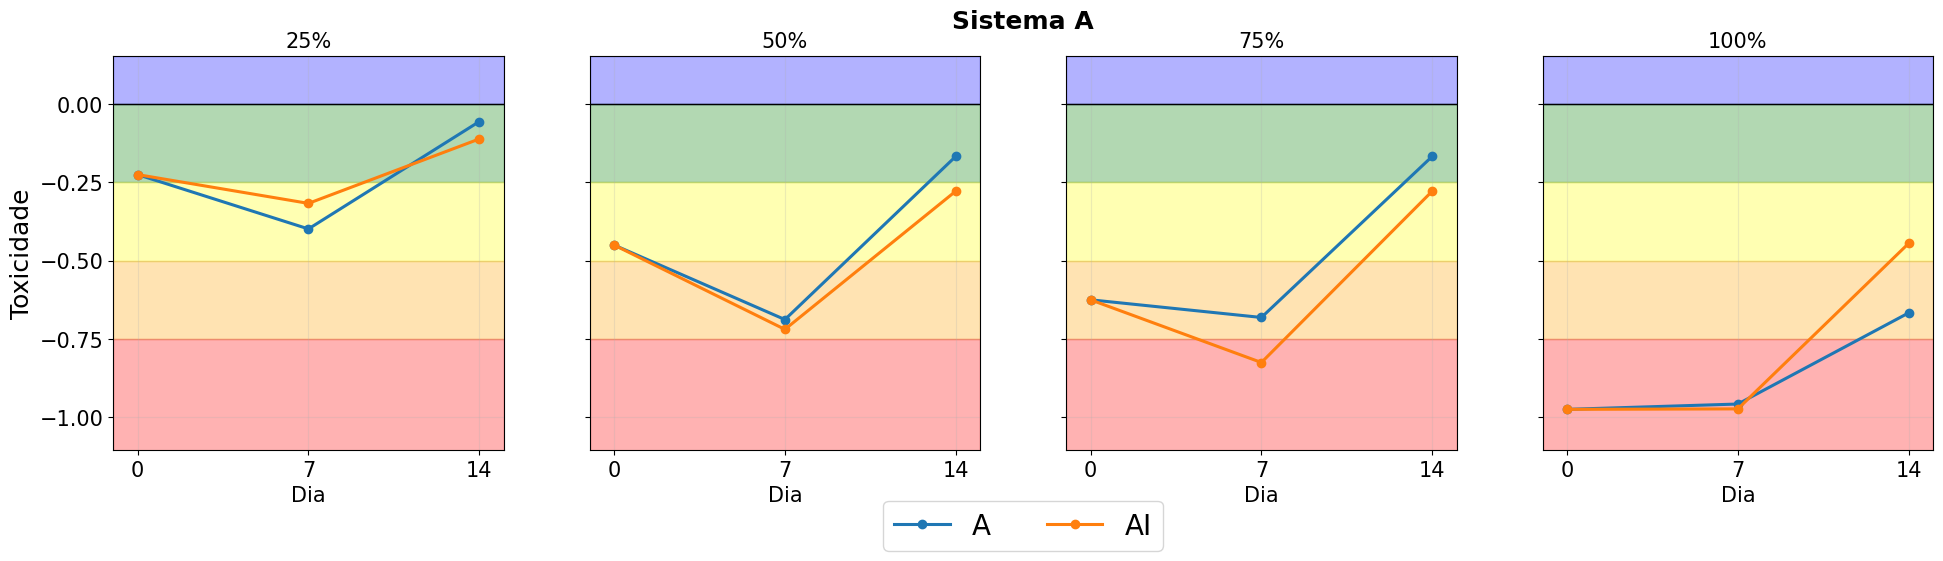

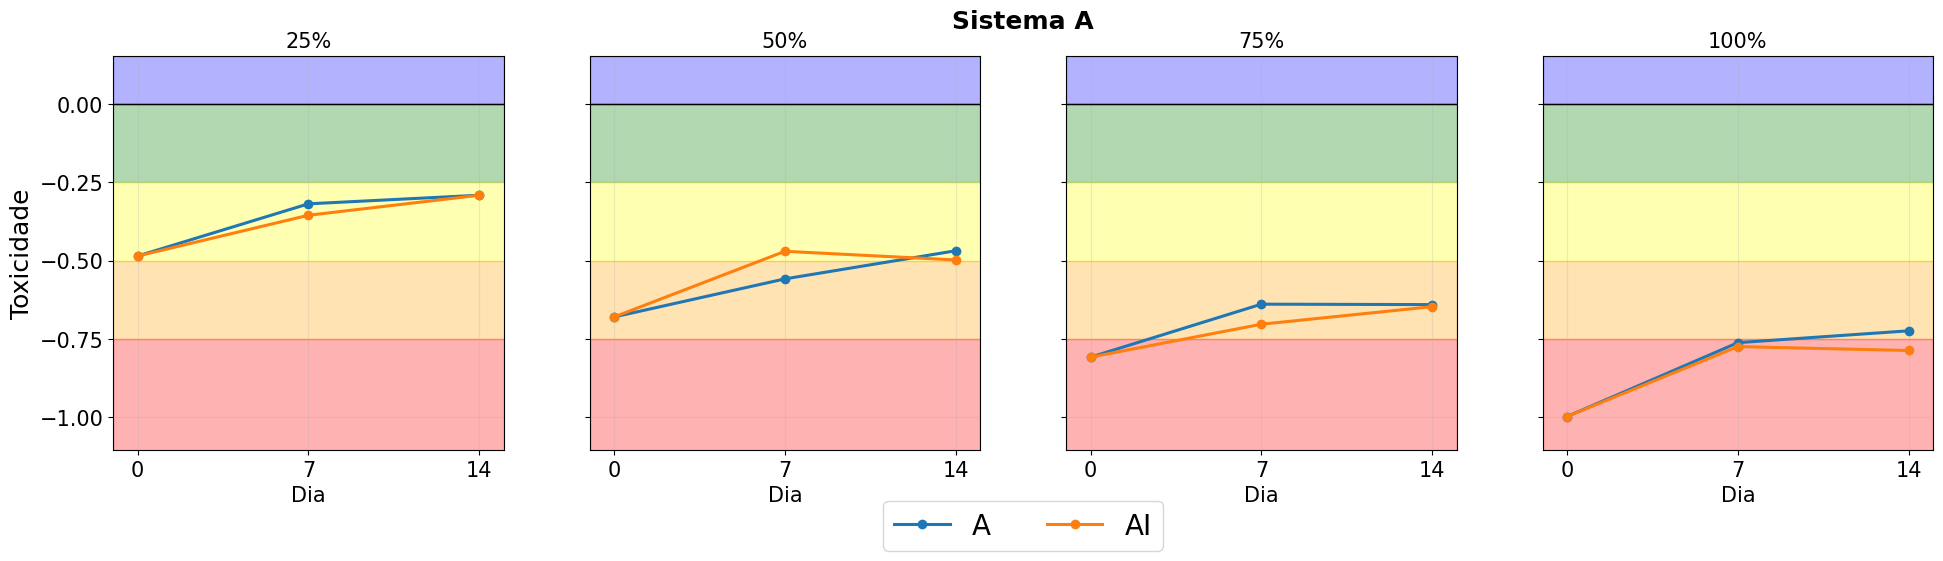

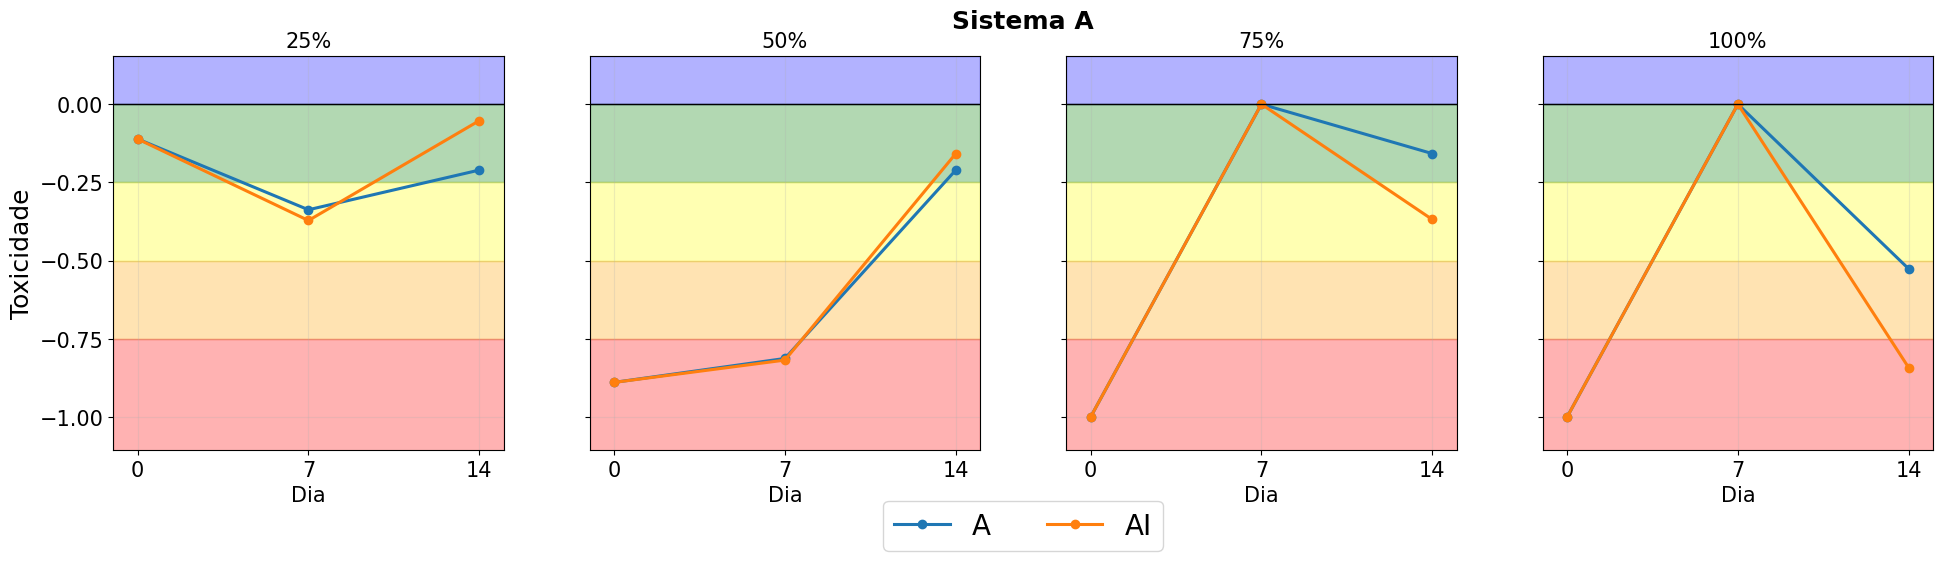

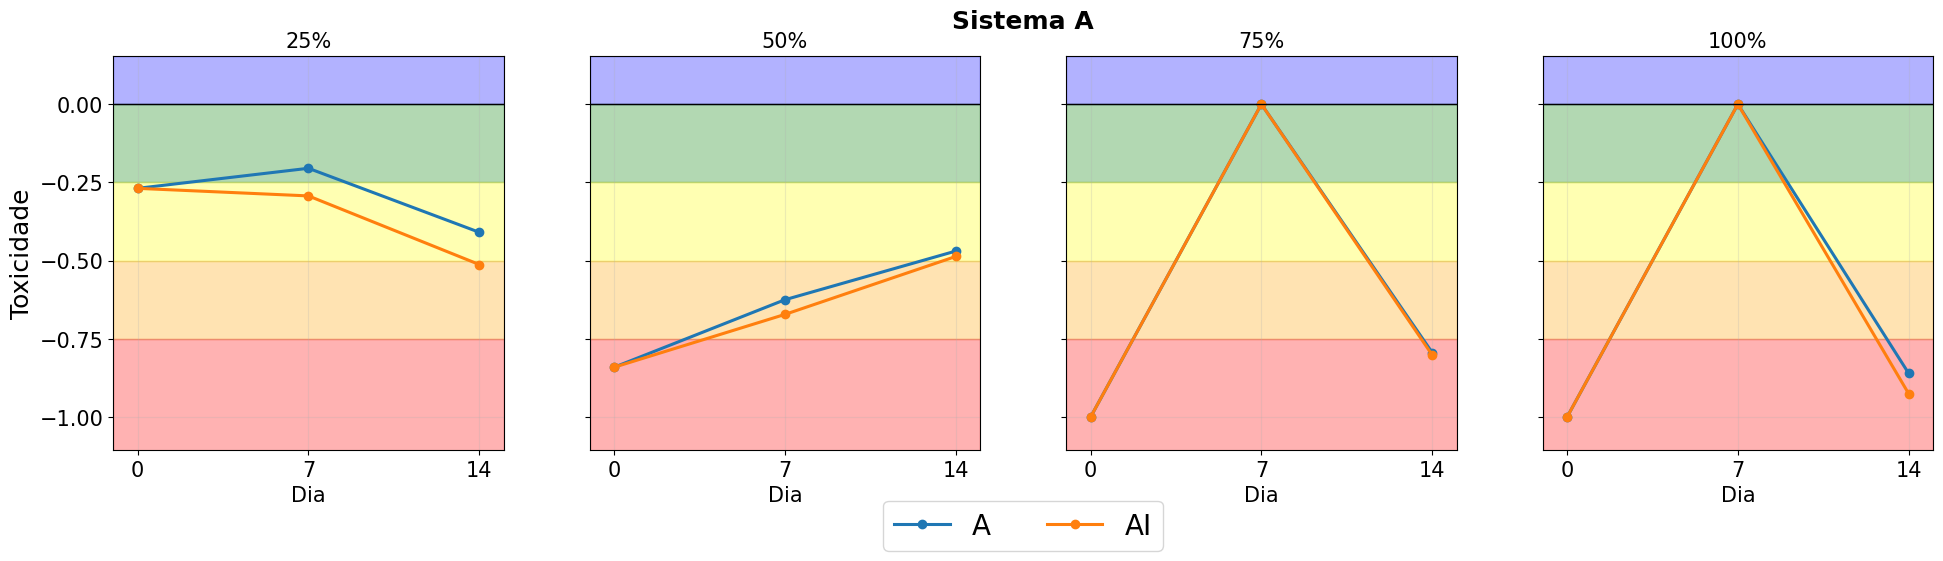

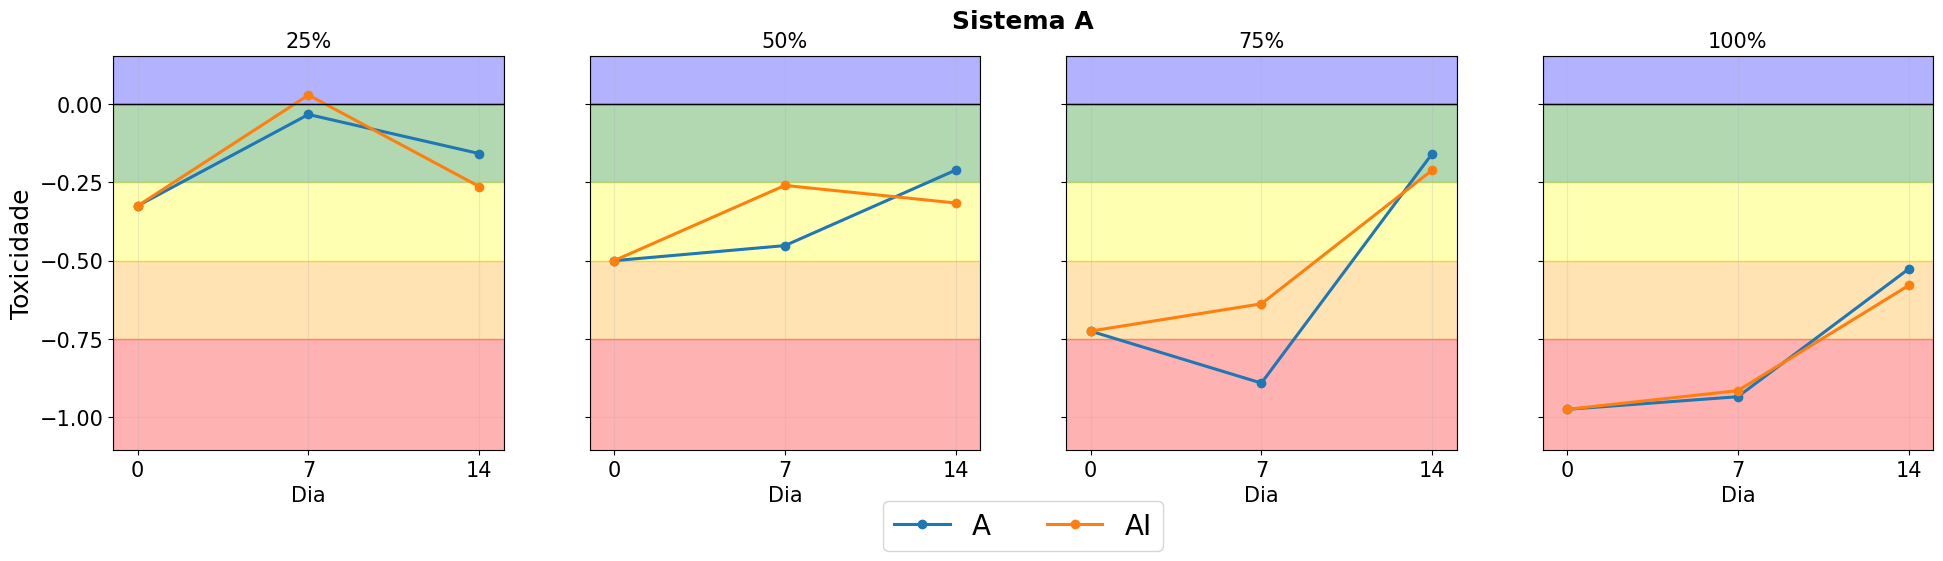

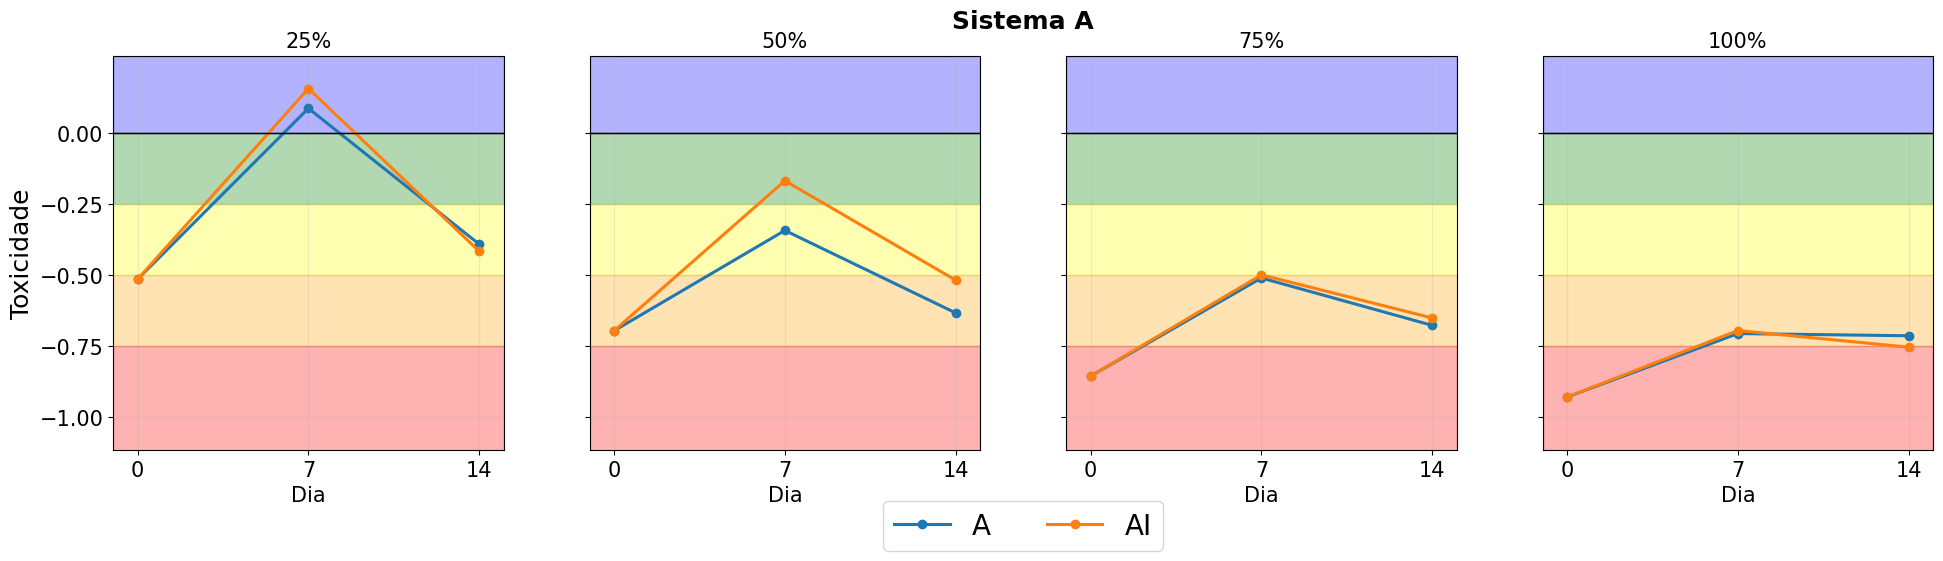

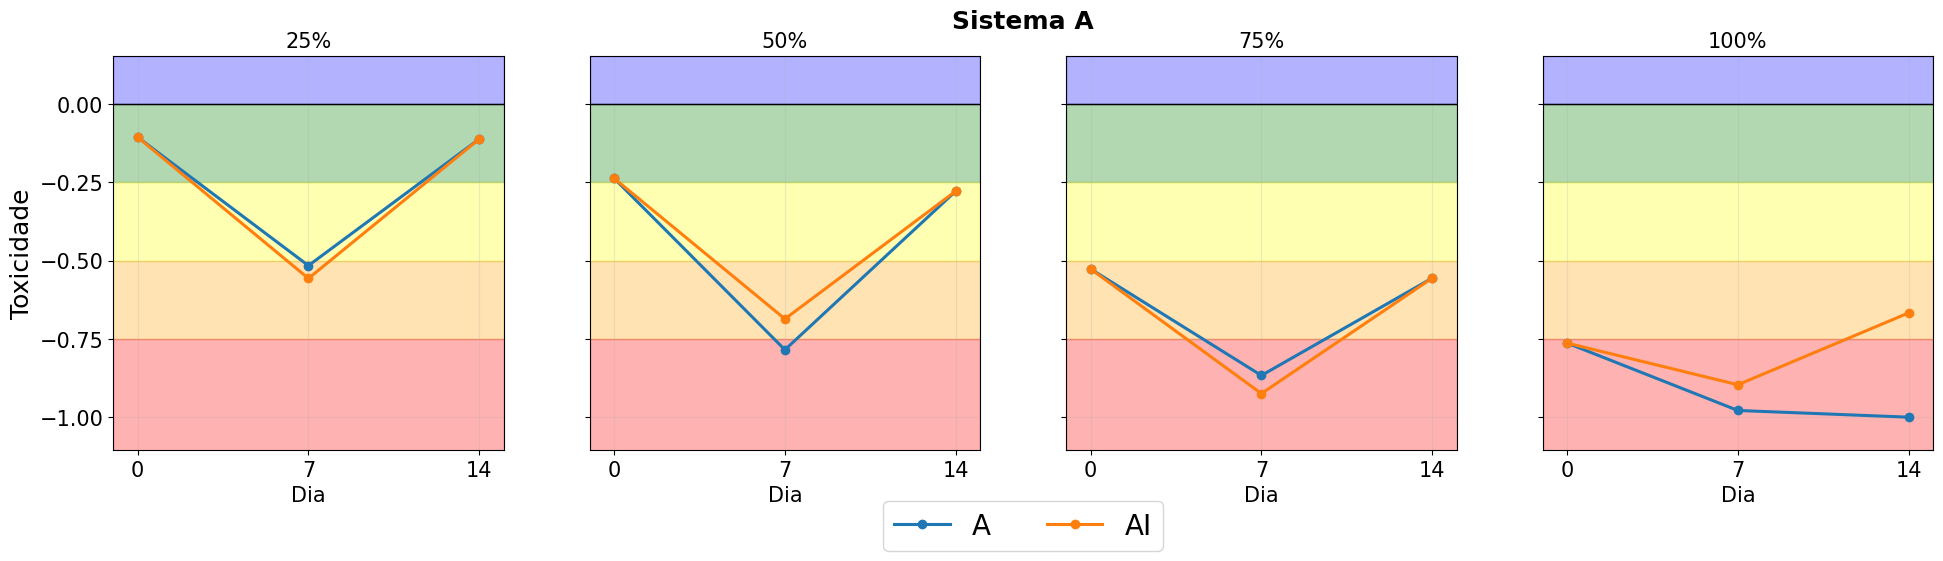

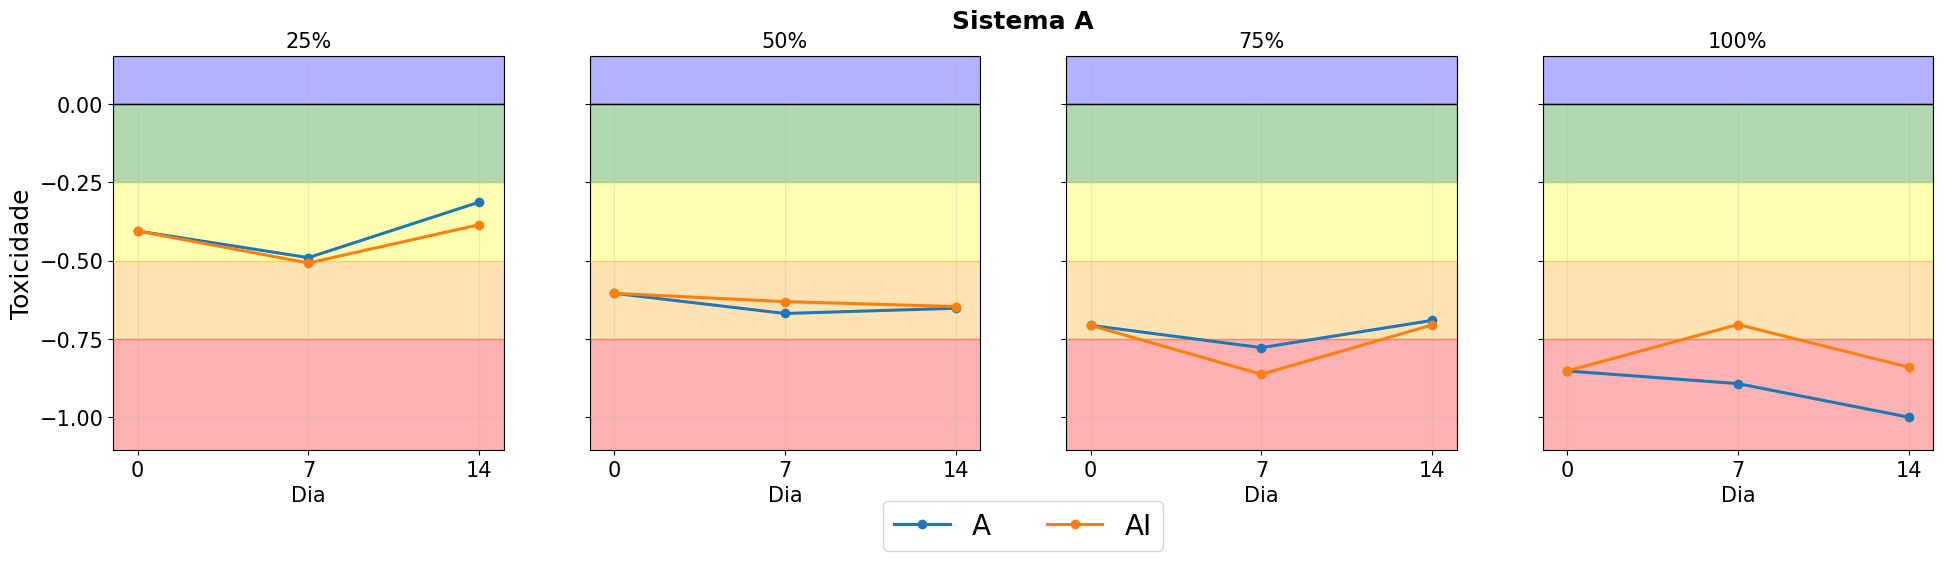

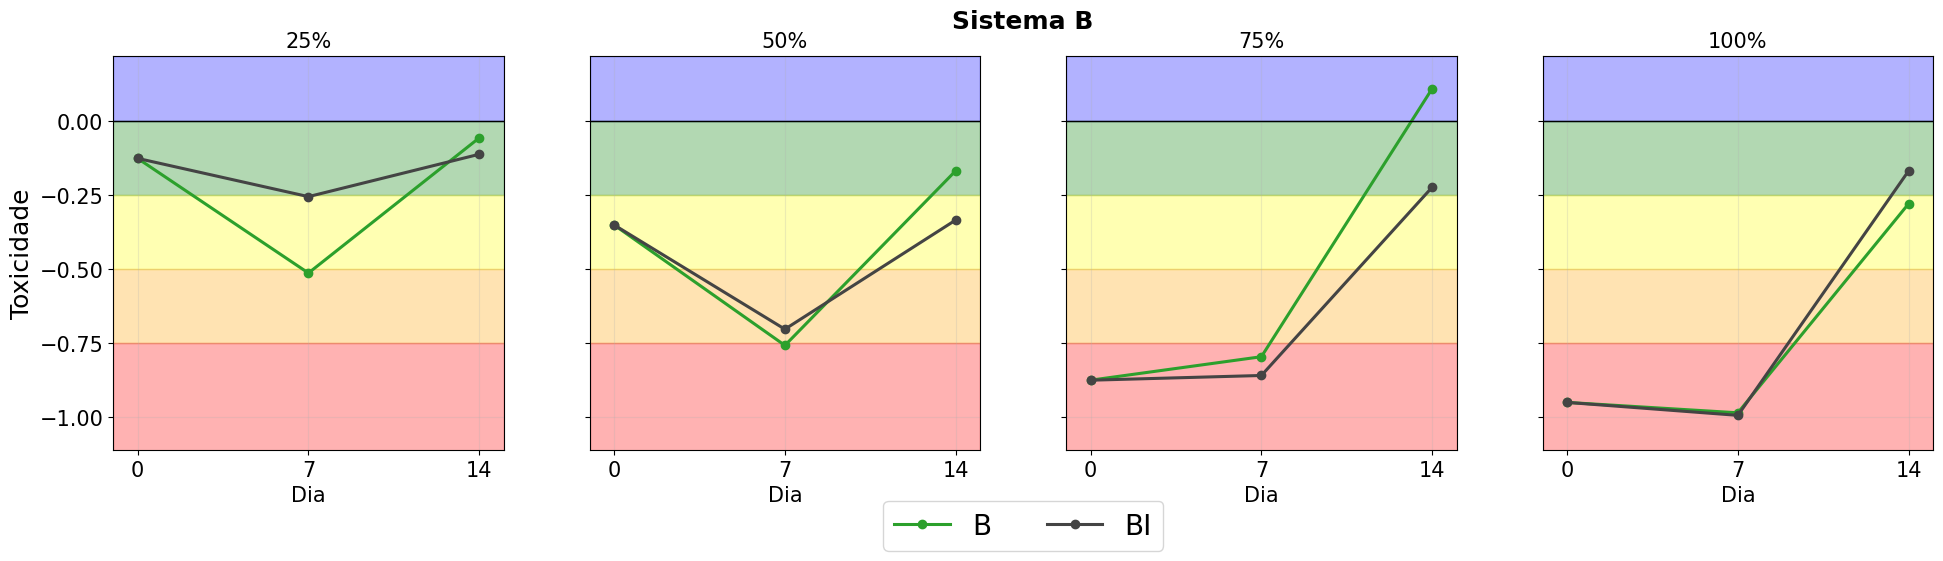

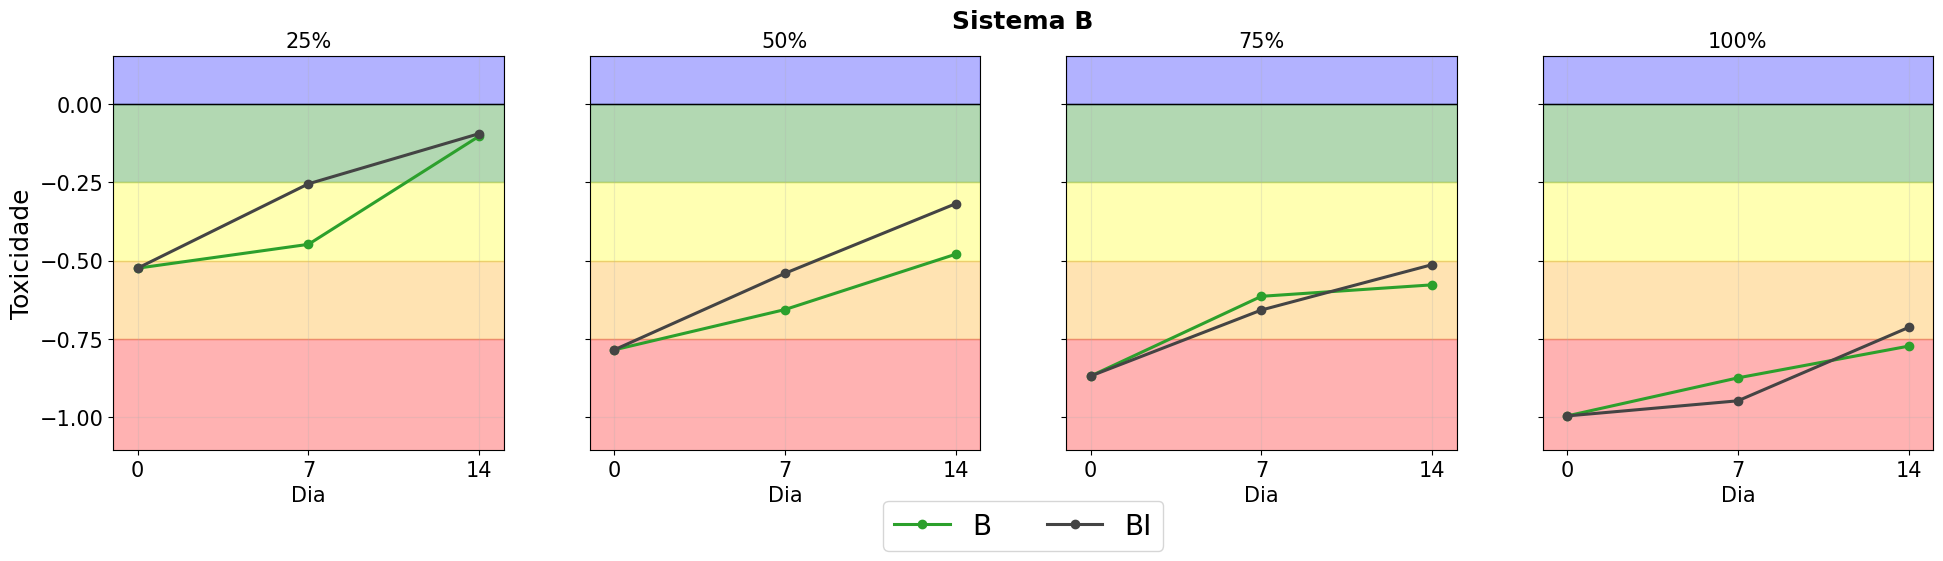

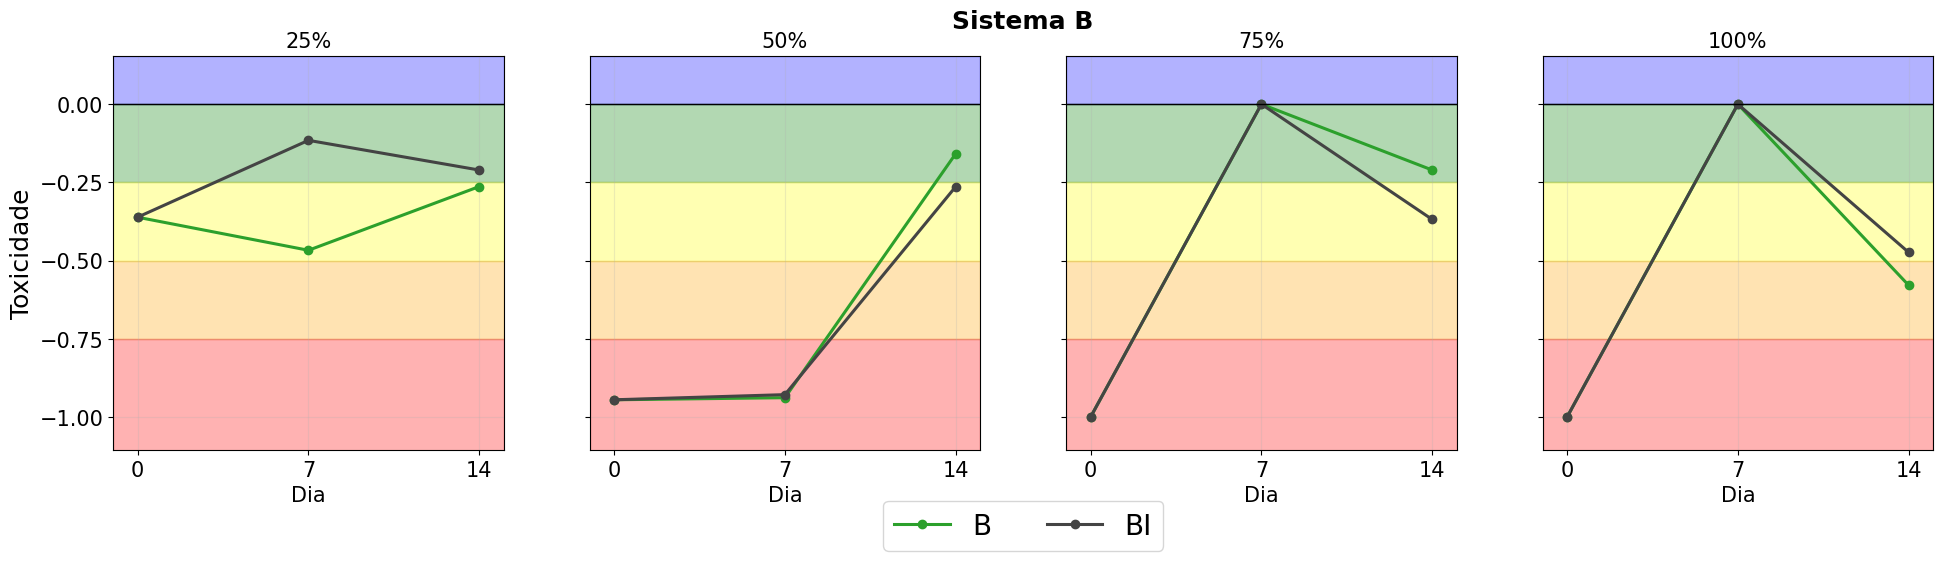

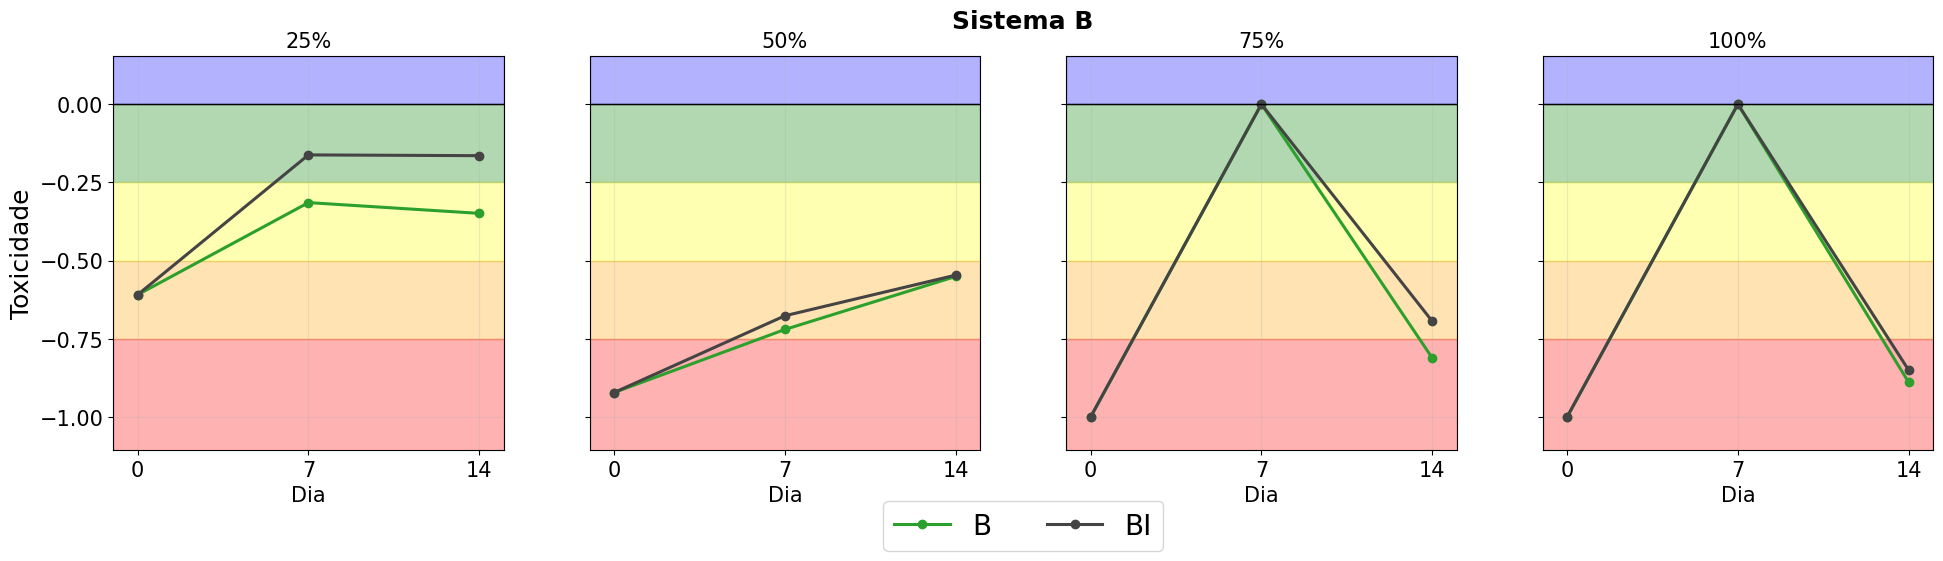

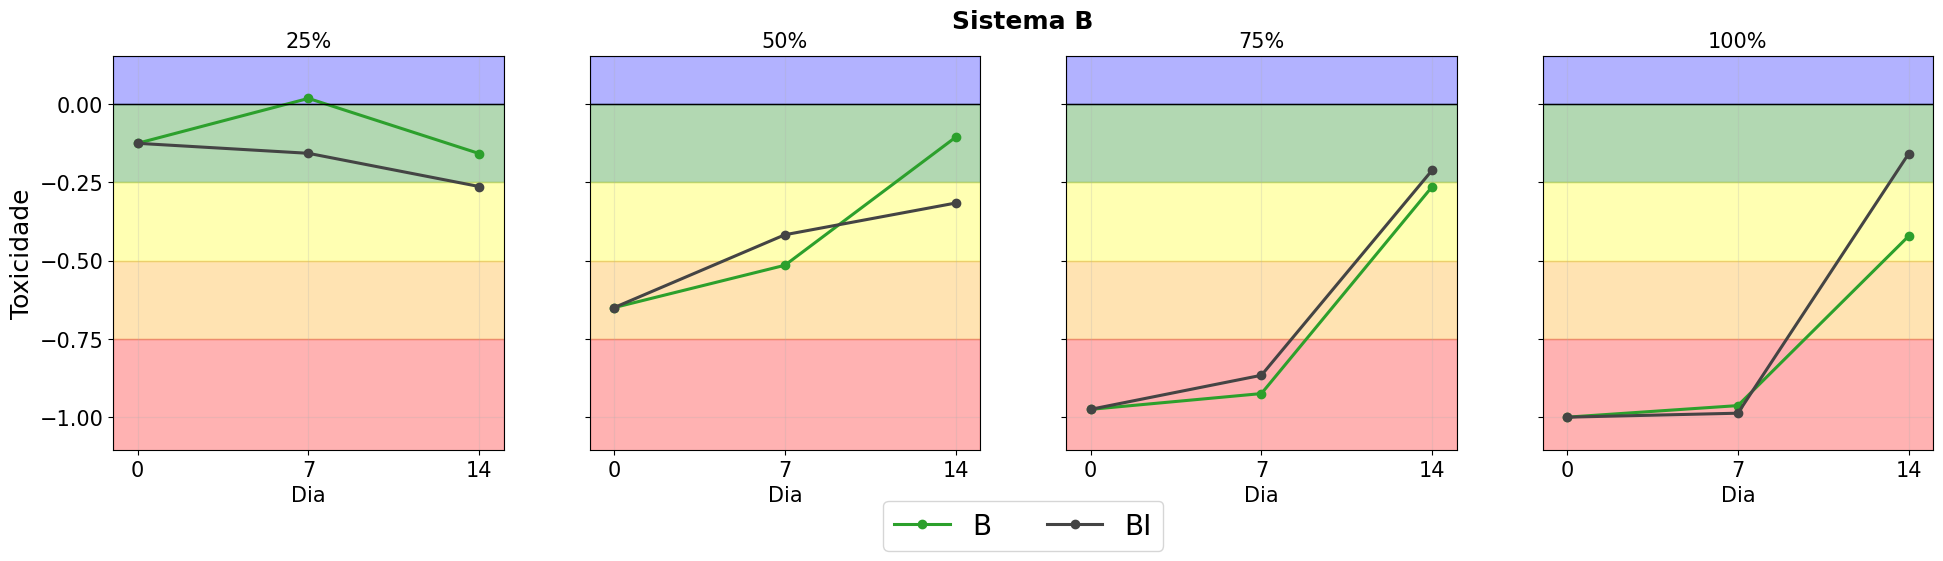

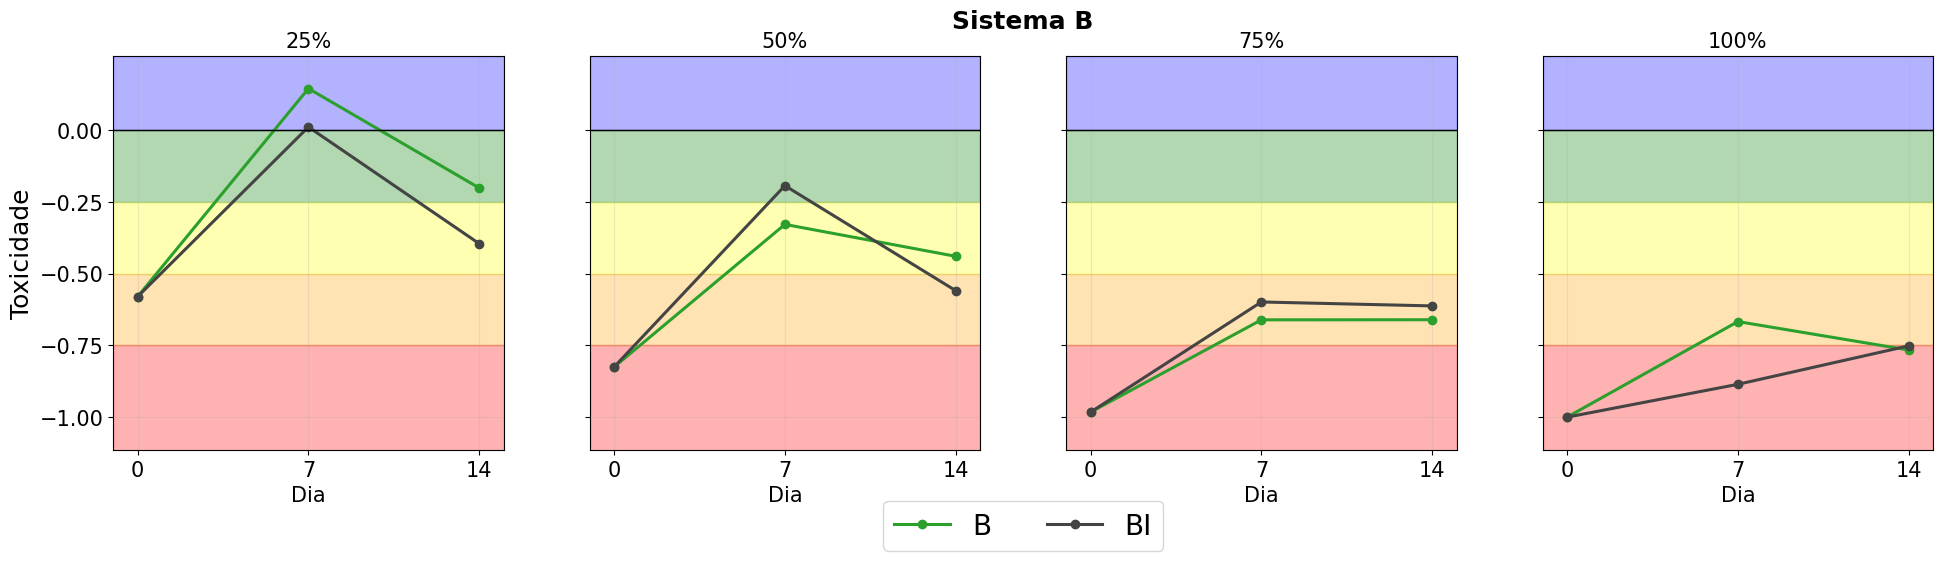

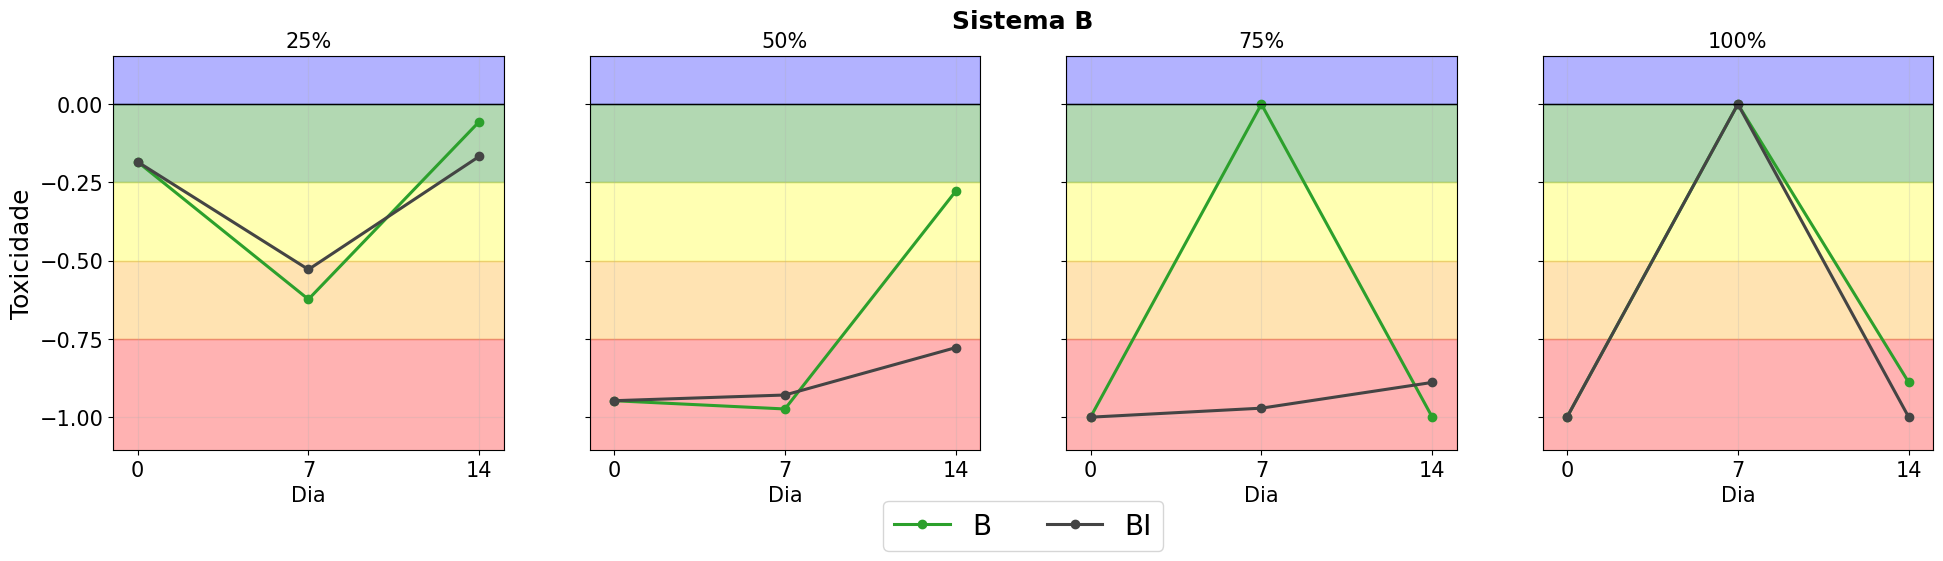

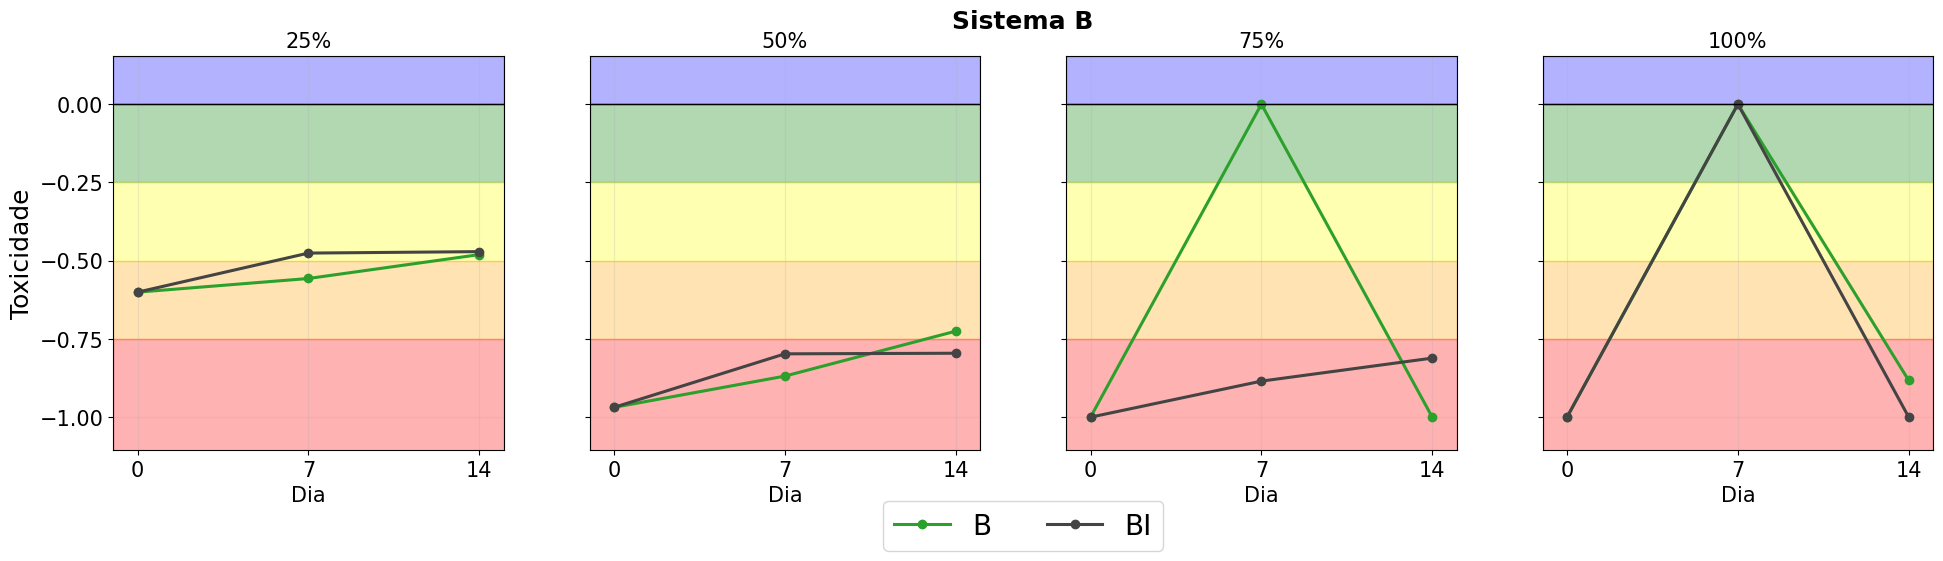

In [19]:
import os
import re
from itertools import product
import matplotlib.pyplot as plt

# Optional: avoid popping up windows / slowing down batch runs
plt.ioff()

def _slug(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9._-]+", "", s)
    return s

out_dir = "plots_delta_lines"
os.makedirs(out_dir, exist_ok=True)

sistemas = ["A", "B"]
fungos = ["Candida", "Aspergillius", "Saccharomyces", "Penicillium"]
analises = ["IGN", "IER"]  # if you meant two, put them here (e.g., ["IGN", "IER"])

for sistema, fungo, analise in product(sistemas, fungos, analises):
    # Skip combos with no data (avoids saving empty plots)
    mask = (
        df["fungo"].astype(str).str.contains(fungo, case=False, na=False)
        & df["analise"].astype(str).str.contains(analise, case=False, na=False)
        & df["sistema"].astype(str).isin([sistema, f"{sistema}I"])
        & (pd.to_numeric(df["concentracao"], errors="coerce") != 0)
    )
    if not mask.any():
        continue

    fig, axes = plot_delta_lines(
        df,
        fungo=fungo,
        sistema=sistema,
        analise=analise,
        toxicity_bands=True,
    )

    base = f"{_slug(fungo)}-{_slug(sistema)}-{_slug(analise)}"
    fig.savefig(os.path.join(out_dir, f"{base}.png"), dpi=300, bbox_inches="tight")

    plt.close(fig)  # important in loops


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Literal


def plot_heatmap(
    analise: str = "IER",
    *,
    modo: Literal["delta_sistema", "delta_tempo_inoculado"] = "delta_sistema",
    valor_em_porcentagem: bool = True,
    fungi_order: list[str] | None = None,
    figsize: tuple[int, int] = (10, 6),
    annot: bool = True,
    # --- outlier controls ---
    filtrar_outliers: bool = False,
    metodo_outlier: Literal["mad", "quantile"] = "mad",
    limiar_mad: float = 3.5,
    quantile_min: float = 0.02,
    quantile_max: float = 0.98,
):
    """
    Heatmap of deltas (day 14 focus), with two modes.

    Modes
    -----
    delta_sistema:
        Compares inoculated vs non-inoculated systems at day 14:
            AI - A
            BI - B

        The legend/top labels correctly show AI and BI.

    delta_tempo_inoculado:
        Compares temporal change inside inoculated systems:
            AI day14 - AI day0
            BI day14 - BI day0

    Outliers
    --------
    If filtrar_outliers=True:
      - outlier cells are masked from the heatmap scale
      - outlier cells are annotated as "-"
    """

    global df  # uses notebook df

    if fungi_order is None:
        fungi_order = ["Candida", "Saccharomyces", "Aspergillius", "Penicillium"]

    keys_sistema = ["fungo", "concentracao", "dia", "analise"]
    keys_tempo = ["fungo", "concentracao", "analise", "sistema"]

    def pct_delta(num: pd.Series, den: pd.Series) -> pd.Series:
        den_abs = den.abs()
        out = np.where(den_abs.ne(0), num * 100 / den_abs, np.nan)
        return pd.Series(out, index=num.index)

    # -----------------------------
    # Build heatmap_df + x-label metadata
    # -----------------------------
    col_tuples: list[tuple[str, str]]

    if modo == "delta_sistema":
        df_14 = df[(df["analise"] == analise) & (df["dia"] == 14)].copy()

        df_A = df_14[df_14["sistema"] == "A"]
        df_AI = df_14[df_14["sistema"] == "AI"]
        df_B = df_14[df_14["sistema"] == "B"]
        df_BI = df_14[df_14["sistema"] == "BI"]

        mA = df_AI.merge(df_A, on=keys_sistema, suffixes=("_AI", "_A"))
        mB = df_BI.merge(df_B, on=keys_sistema, suffixes=("_BI", "_B"))

        outA = mA[keys_sistema].copy()
        rawA = mA["valor_AI"] - mA["valor_A"]
        outA["valor"] = pct_delta(rawA, mA["valor_A"]) if valor_em_porcentagem else rawA
        outA["coluna"] = outA["fungo"] + " AI"

        outB = mB[keys_sistema].copy()
        rawB = mB["valor_BI"] - mB["valor_B"]
        outB["valor"] = pct_delta(rawB, mB["valor_B"]) if valor_em_porcentagem else rawB
        outB["coluna"] = outB["fungo"] + " BI"

        df_out = pd.concat([outA, outB], ignore_index=True)

        heatmap_df = (
            df_out.pivot(index="concentracao", columns="coluna", values="valor")
            .sort_index()
        )

        ordered_columns = []
        col_tuples = []
        for f in fungi_order:
            ordered_columns += [f"{f} AI", f"{f} BI"]
            col_tuples += [("AI", f), ("BI", f)]
        heatmap_df = heatmap_df.reindex(columns=ordered_columns)

        suffix = "%" if valor_em_porcentagem else ""
        title = f"{analise}{suffix} — Delta por sistema (Dia 14: AI−A, BI−B)"
        cbar_label = f"{analise}{suffix}"
        annotate_as_percent = bool(valor_em_porcentagem)

    elif modo == "delta_tempo_inoculado":
        df_i = df[
            (df["analise"] == analise)
            & (df["sistema"].isin(["AI", "BI"]))
            & (df["dia"].isin([0, 14]))
        ].copy()

        df_0 = df_i[df_i["dia"] == 0].copy()
        df_14 = df_i[df_i["dia"] == 14].copy()

        m = df_14.merge(df_0, on=keys_tempo, suffixes=("_14", "_0"))

        out = m[keys_tempo].copy()
        raw = m["valor_14"] - m["valor_0"]
        out["valor"] = pct_delta(raw, m["valor_0"]) if valor_em_porcentagem else raw

        out["coluna"] = out["sistema"] + " " + out["fungo"]
        heatmap_df = (
            out.pivot(index="concentracao", columns="coluna", values="valor")
            .sort_index()
        )

        ordered_columns = []
        col_tuples = []
        for f in fungi_order:
            ordered_columns += [f"AI {f}", f"BI {f}"]
            col_tuples += [("AI", f), ("BI", f)]
        heatmap_df = heatmap_df.reindex(columns=ordered_columns)

        suffix = "%" if valor_em_porcentagem else ""
        title = f"{analise}{suffix} — Delta temporal (Inoculado: Dia 14 − Dia 0)"
        cbar_label = f"{analise}{suffix}"
        annotate_as_percent = bool(valor_em_porcentagem)

    else:
        raise ValueError("modo must be 'delta_sistema' or 'delta_tempo_inoculado'")

    # -----------------------------
    # Outlier mask
    # -----------------------------
    outlier_mask = pd.DataFrame(False, index=heatmap_df.index, columns=heatmap_df.columns)

    if filtrar_outliers:
        vals = heatmap_df.to_numpy(dtype=float)
        finite_vals = vals[np.isfinite(vals)]

        if finite_vals.size > 0:
            if metodo_outlier == "mad":
                med = np.median(finite_vals)
                mad = np.median(np.abs(finite_vals - med))

                if mad > 0:
                    robust_z = 0.6745 * (heatmap_df - med) / mad
                    outlier_mask = robust_z.abs() > limiar_mad

            elif metodo_outlier == "quantile":
                q_low = np.nanquantile(finite_vals, quantile_min)
                q_high = np.nanquantile(finite_vals, quantile_max)
                outlier_mask = (heatmap_df < q_low) | (heatmap_df > q_high)

            else:
                raise ValueError("metodo_outlier must be 'mad' or 'quantile'")

    # mask outliers from plotted values
    plot_df = heatmap_df.mask(outlier_mask)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    data = plot_df.values.astype(float)

    if np.isfinite(data).any():
        vmax = np.nanmax(np.abs(data))
        vmax = 1.0 if (vmax == 0 or np.isnan(vmax)) else vmax
    else:
        vmax = 1.0

    vmin = -vmax

    cmap = plt.cm.RdBu.copy()   # blue=positive, red=negative
    cmap.set_bad(color="#d9d9d9")  # masked cells (outliers / NaN) appear grey

    im = ax.imshow(
        data,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )

    # X ticks
    ncols = len(heatmap_df.columns)
    x = np.arange(ncols)

    top_labels = [sys for (sys, _fungus) in col_tuples]
    ax.set_xticks(x)
    ax.set_xticklabels(top_labels, rotation=0, ha="center")

    xform = ax.get_xaxis_transform()
    for i, f in enumerate(fungi_order):
        x_center = i * 2 + 0.5
        ax.text(x_center, -0.1, f, transform=xform, ha="center", va="top", fontsize=10)

    ax.tick_params(axis="x", pad=3)

    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)

    if annot:
        for i in range(len(heatmap_df.index)):
            for j in range(len(heatmap_df.columns)):
                original_val = heatmap_df.iloc[i, j]
                is_outlier = outlier_mask.iloc[i, j]

                if pd.isna(original_val):
                    continue
                elif is_outlier:
                    txt = "-"
                else:
                    txt = f"{original_val:+.1f}%" if annotate_as_percent else f"{original_val:.2f}"

                ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_title(title)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    plt.show()

    return fig, ax

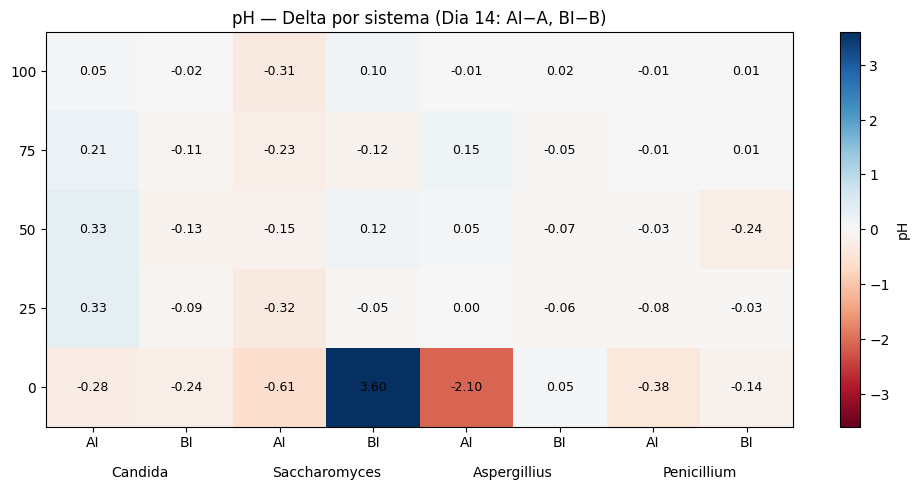

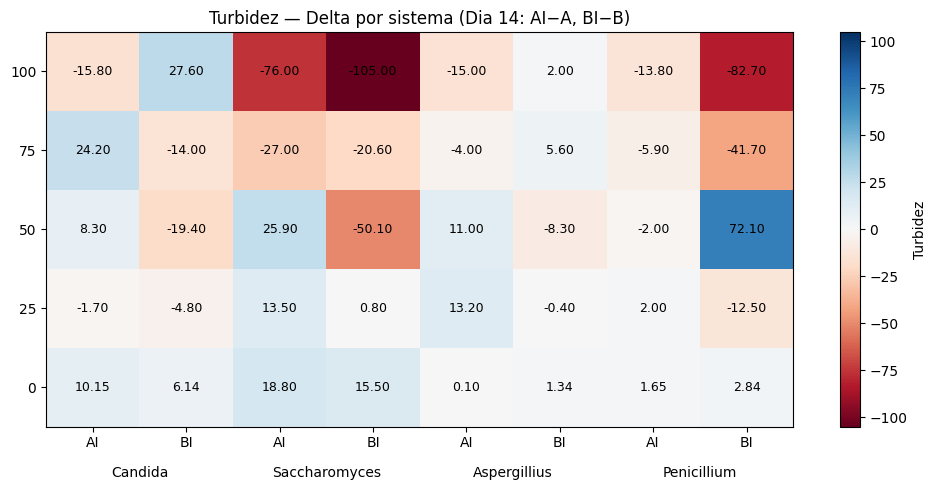

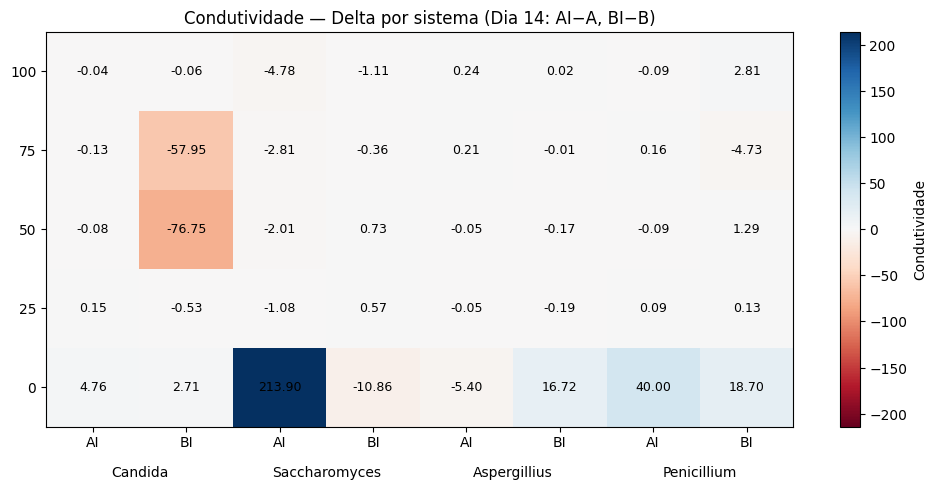

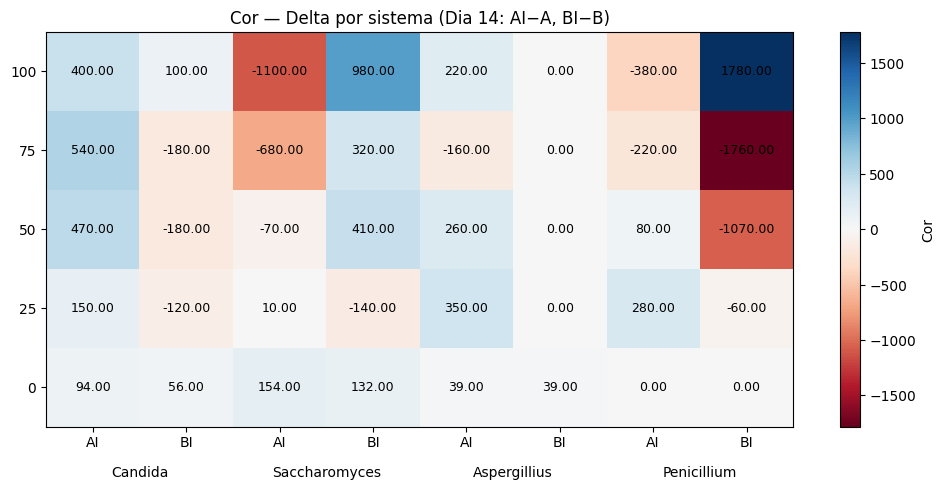

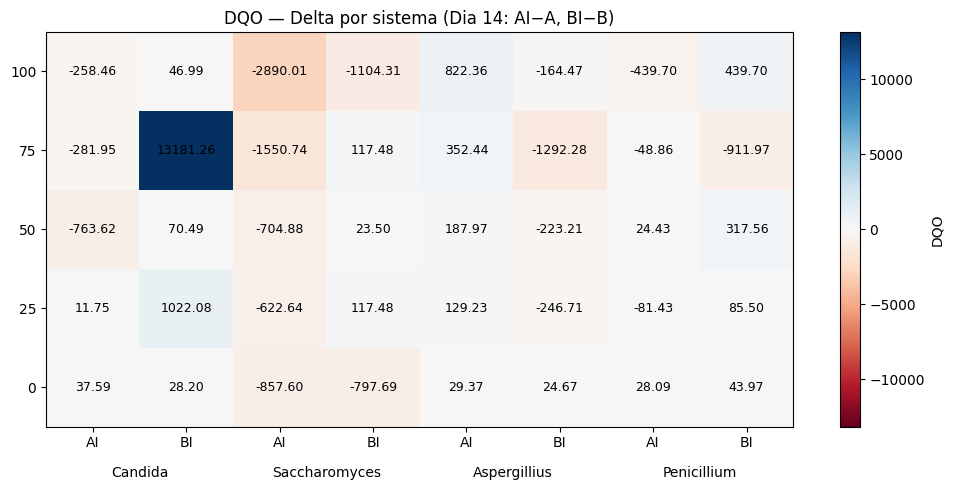

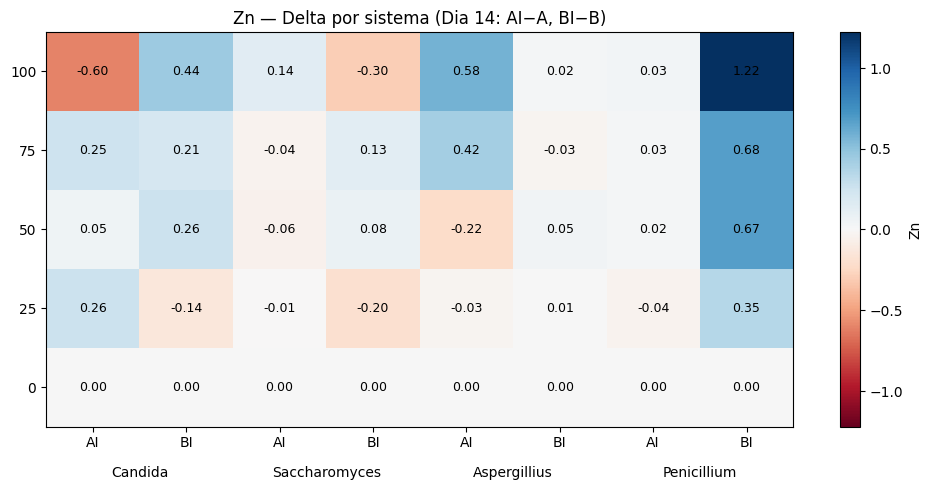

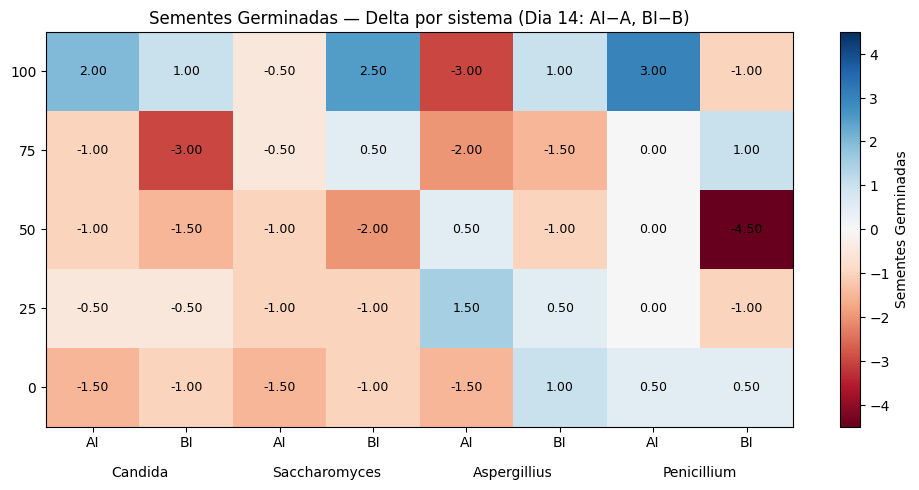

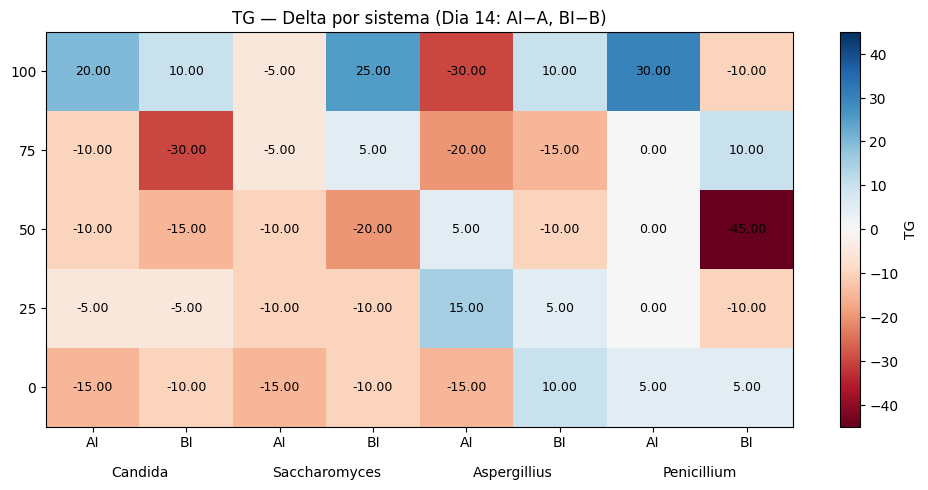

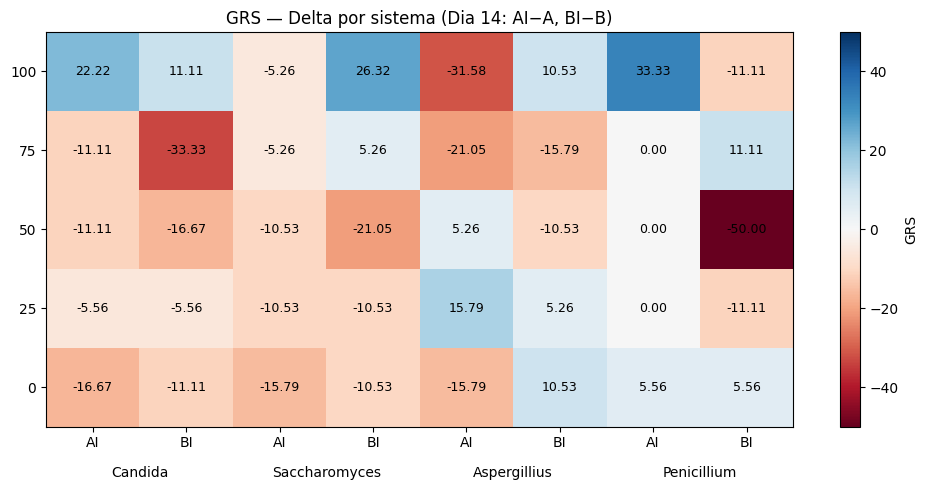

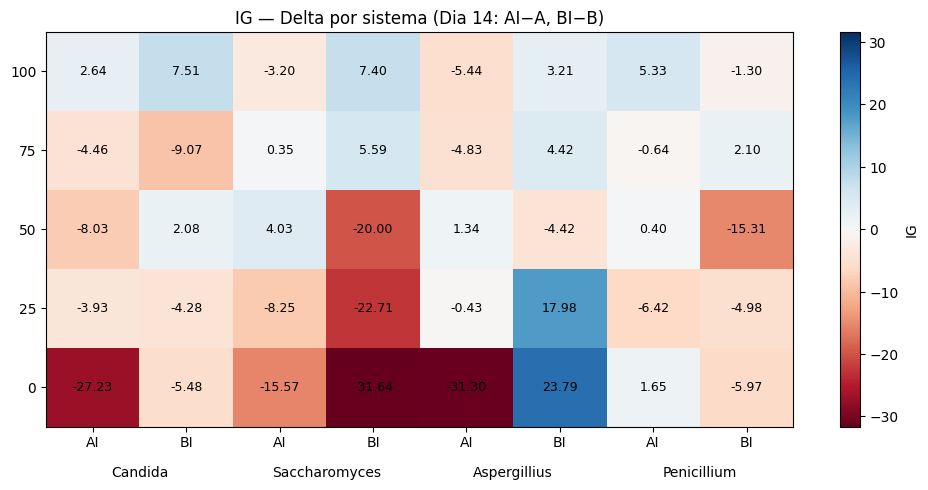

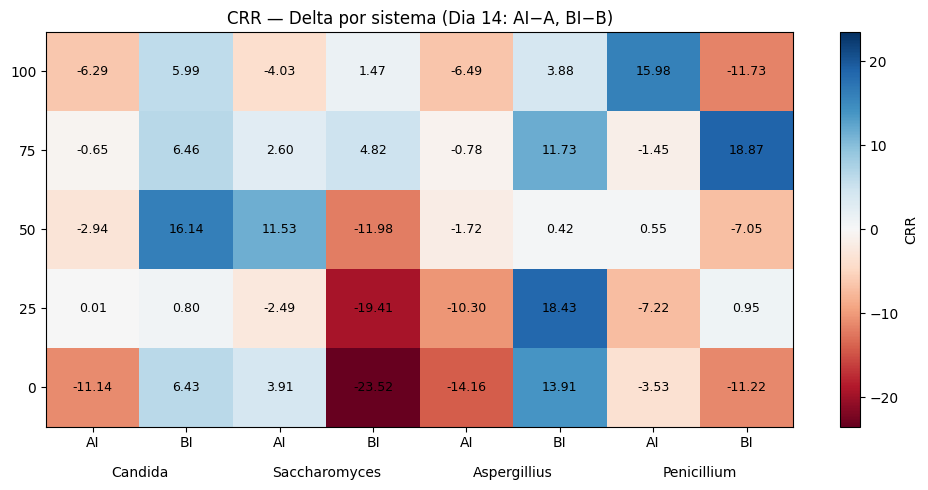

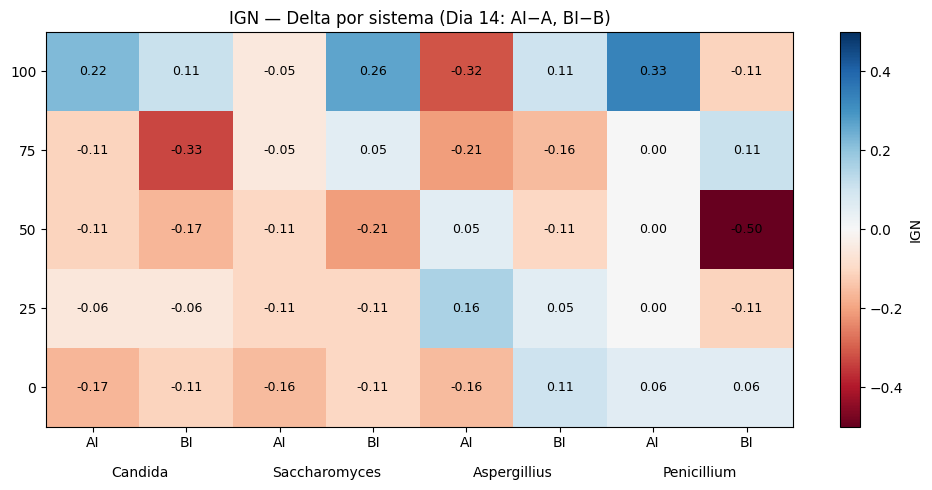

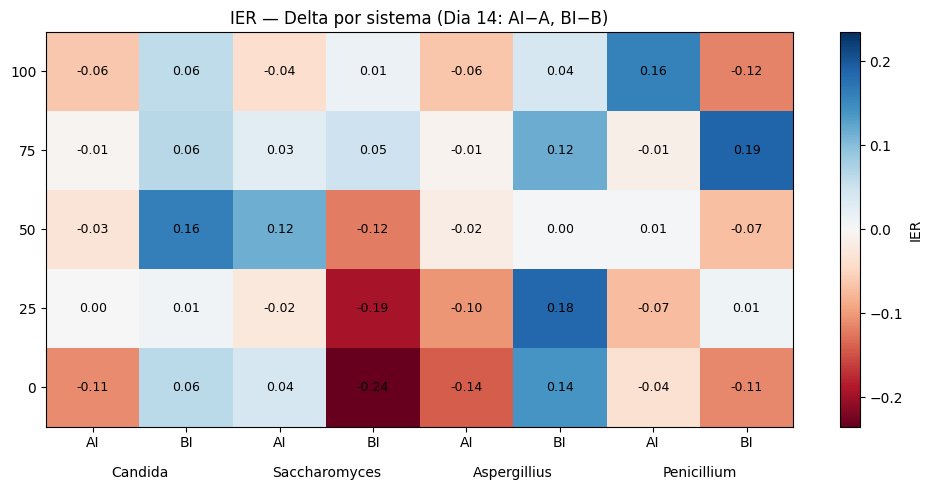

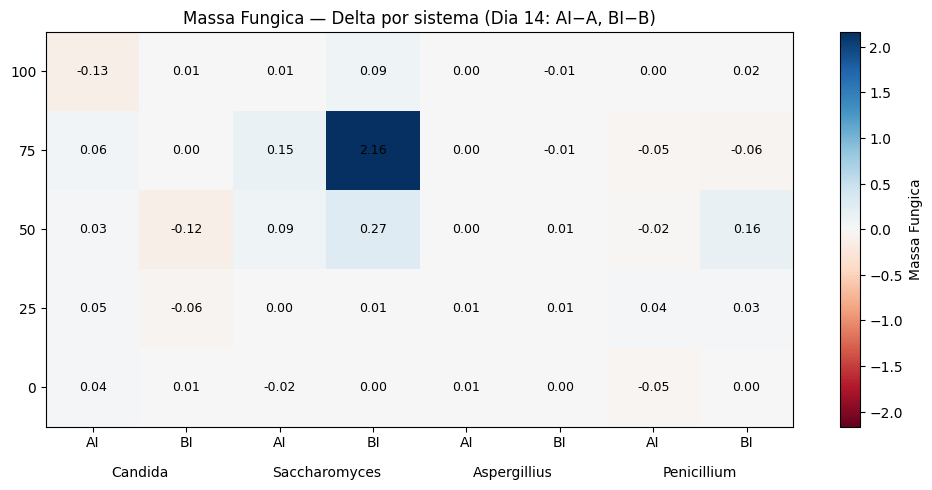

In [28]:

for analise in df["analise"].unique():
    fig, axes = plot_heatmap(
        analise,
        modo="delta_sistema", 
        valor_em_porcentagem=False,
        filtrar_outliers=False,
        metodo_outlier="mad",
        limiar_mad=3.5,)
    
    fig.savefig(f"pots_heatmap/{analise}-delta_tempo.png", dpi=300, bbox_inches="tight")

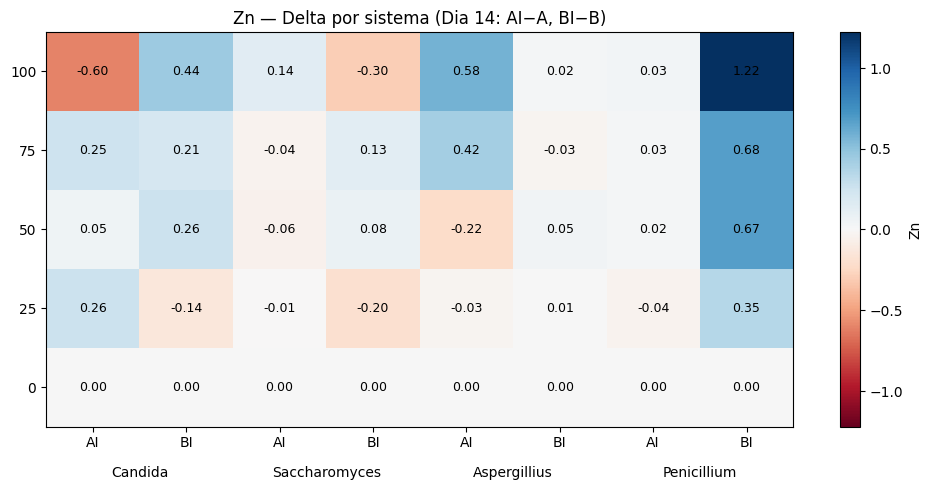

In [27]:
analise = "Zn"
fig, axes = plot_heatmap(
    analise,
    modo="delta_sistema", 
    valor_em_porcentagem=False,
    filtrar_outliers=False,
    metodo_outlier="mad",
    limiar_mad=3.5,)

In [26]:
res = df[(df["analise"] == analise)]
res.to_csv(f"{analise}.csv", index=False)


In [24]:
for analise in df["analise"].unique():
    print(analise)

pH
Turbidez
Condutividade
Cor
DQO
Zn
Sementes Germinadas
TG
GRS
IG
CRR
IGN
IER
Massa Fungica
